In [2]:
!pip install udocker
import os

# Initialize udocker
!udocker install

# Setting up the environment variable for the NGC API Key
os.environ['NGC_API_KEY'] = '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'

# Log in and pull the image using udocker
!udocker login --user='$oauthtoken' --password=$NGC_API_KEY nvcr.io
!udocker pull nvcr.io/nim/nvidia/audio2face-3d:latest

# Run the container
# Note: udocker execution modes may vary (P1, P2, etc.) depending on the environment support
!udocker run --name=audio2face \
  -e NGC_API_KEY=$NGC_API_KEY \
  nvcr.io/nim/nvidia/audio2face-3d:latest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 5.2 MB/s eta 0:00:00
Error: do not run as root !
Error: do not run as root !
Error: do not run as root !
Error: do not run as root !


In [1]:
!pip install udocker -q
import os

# Ensure non-root user exists
!id -u colabuser &>/dev/null || useradd -m colabuser

# Define the full API key
full_api_key = "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"
os.environ['NGC_API_KEY'] = full_api_key

# Install udocker tools for the user
!sudo -u colabuser udocker install

# Login using escaping that works for udocker's parser
!sudo -u colabuser udocker login --user='$oauthtoken' --password="{full_api_key}" nvcr.io

# Pull the specific NIM image
!sudo -u colabuser udocker pull nvcr.io/nim/nvidia/audio2face-3d:latest

# Run the container
!sudo -u colabuser udocker run --name=audio2face \
  -e NGC_API_KEY="{full_api_key}" \
  nvcr.io/nim/nvidia/audio2face-3d:latest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.6/119.6 kB 5.0 MB/s eta 0:00:00
Info: creating repo: /home/colabuser/.udocker
Info: udocker command line interface 1.3.17
Info: searching for udockertools >= 1.2.11
Info: installing udockertools 1.2.11
Info: installation of udockertools successful
Error: syntax error at: --user=$oauthtoken nvcr.io
Error: manifest not found or not authorized
Error: no files downloaded
Error: manifest not found or not authorized
Error: no files downloaded
Error: image or container not available


In [7]:
import os
import glob

# The client seems to have created a timestamped directory
client_path = '/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client'
run_dir = os.path.join(client_path, '20260313_164028_485263')

if os.path.exists(run_dir):
    print(f"Checking contents of run directory: {run_dir}")
    files = os.listdir(run_dir)
    for f in files:
        full_path = os.path.join(run_dir, f)
        print(f"[FOUND] {f} - Size: {os.path.getsize(full_path)} bytes")
else:
    print("Run directory not found.")

Checking contents of run directory: /content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client/20260313_164028_485263
[FOUND] a2f_input_emotions.csv - Size: 328 bytes
[FOUND] out.wav - Size: 406444 bytes
[FOUND] a2f_smoothed_emotion_output.csv - Size: 54527 bytes
[FOUND] animation_frames.csv - Size: 349526 bytes


In [2]:
# Clone the NVIDIA ACE samples repository
!git clone https://github.com/NVIDIA/Audio2Face-3D-Samples.git
%cd Audio2Face-3D-Samples/scripts/audio2face_3d_api_client

# Install the necessary proto wheel and requirements
!pip install ../../proto/sample_wheel/nvidia_ace-1.2.0-py3-none-any.whl
!pip install -r requirements.txt

Cloning into 'Audio2Face-3D-Samples'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 200 (delta 83), reused 184 (delta 73), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 4.57 MiB | 10.46 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client
Processing /content/Audio2Face-3D-Samples/proto/sample_wheel/nvidia_ace-1.2.0-py3-none-any.whl
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of grpcio-tools to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-tools to determine w

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [7]:
import os

# Path to the A2F client
repo_root = '/content/Audio2Face-3D-Samples'
client_path = os.path.join(repo_root, 'scripts/audio2face_3d_api_client')

# Ensure repository exists
if not os.path.exists(repo_root):
    print("Cloning repository...")
    !git clone https://github.com/NVIDIA/Audio2Face-3D-Samples.git {repo_root}

# Navigate to the correct directory
%cd {client_path}

# API Configuration
API_KEY = "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"
CLAIRE_FUNCTION_ID = "0961a6da-fb9e-4f2e-8491-247e5fd7bf8d"

# Determine target audio: User provided path or default example
if 'custom_audio_path' in locals() and os.path.exists(custom_audio_path):
    target_audio = custom_audio_path
else:
    target_audio = '../../example_audio/Claire_neutral.wav'

print(f"Processing: {target_audio}")

# Execute NIM Client
!python ./nim_a2f_3d_client.py \
    {target_audio} \
    config/config_claire.yml \
    --apikey {API_KEY} \
    --function-id {CLAIRE_FUNCTION_ID}

Cloning repository...
Cloning into '/content/Audio2Face-3D-Samples'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 200 (delta 83), reused 184 (delta 73), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 4.57 MiB | 14.30 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client
Processing: ../../example_audio/Claire_neutral.wav
Traceback (most recent call last):
  File "/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client/./nim_a2f_3d_client.py", line 18, in <module>
    import a2f_3d.client.service
  File "/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client/a2f_3d/client/service.py", line 19, in <module>
    from nvidia_ace.animation_data.v1_pb2 import AnimationData, AnimationDataStreamHeader
ModuleNotFoundError: No module named 'nvidia_ace'


In [1]:
import os

# @title User Input for Animation Generation
# Provide the path to your own WAV file here
custom_audio_path = "../../example_audio/Claire_neutral.wav" # @param {type:"string"}

if not os.path.exists(custom_audio_path):
    print(f"Warning: {custom_audio_path} not found. Please check the path.")
else:
    print(f"Using audio file: {custom_audio_path}")

In [6]:
import pandas as pd
import os
import glob
from sklearn.model_selection import train_test_split

# Search for the animation CSV in the sample_data directory as specified
search_path = '/content/sample_data'
csv_pattern = os.path.join(search_path, '**/animation_frames.csv')
found_files = glob.glob(csv_pattern, recursive=True)

# If not found with that name, look for any CSV in sample_data to be helpful
if not found_files:
    found_files = glob.glob(os.path.join(search_path, '*.csv'))

if found_files:
    csv_path = found_files[0]
    df = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded from: {csv_path}")

    # Split data: 80% Training, 20% Testing
    # Using all available columns as features for the split demo
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print(f"Total rows in CSV: {len(df)}")
    print(f"Training Set size: {len(train_df)}")
    print(f"Testing Set size: {len(test_df)}")

    print("\nFirst 5 rows of Training Data:")
    display(train_df.head())
else:
    print(f"No CSV files found in {search_path}. Please ensure your data is uploaded there.")

Dataset successfully loaded from: /content/sample_data/california_housing_train.csv
Total rows in CSV: 17000
Training Set size: 13600
Testing Set size: 3400

First 5 rows of Training Data:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
4679,-118.07,33.81,22.0,2711.0,352.0,1305.0,368.0,8.5407,398800.0
2512,-117.63,33.50,12.0,3619.0,536.0,1506.0,492.0,7.2013,353600.0
993,-117.09,32.57,17.0,444.0,83.0,357.0,87.0,5.1478,138900.0
1327,-117.16,32.81,34.0,2275.0,375.0,1021.0,379.0,3.6371,176300.0
4630,-118.07,34.17,36.0,2415.0,394.0,1215.0,413.0,5.5418,326100.0


In [8]:
# 1. Install required dependencies and the NVIDIA ACE proto wheel
import os
repo_root = '/content/Audio2Face-3D-Samples'
if not os.path.exists(repo_root):
    !git clone https://github.com/NVIDIA/Audio2Face-3D-Samples.git {repo_root}

%cd {repo_root}/scripts/audio2face_3d_api_client
!pip install ../../proto/sample_wheel/nvidia_ace-1.2.0-py3-none-any.whl -q
!pip install -r requirements.txt -q
print('Dependencies installed successfully.')

/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.4/311.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 71.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.24.1 which is incompatible.
google-api-core 2.30.0 requires protobuf<7.0.0,>=4.25.8, but you have protobuf 4.24.1 whi

In [4]:
import os
import pandas as pd
import glob
from sklearn.model_selection import train_test_split

# 1. Setup repository and dependencies if missing
repo_root = '/content/Audio2Face-3D-Samples'
if not os.path.exists(repo_root):
    print("Cloning repository...")
    !git clone https://github.com/NVIDIA/Audio2Face-3D-Samples.git {repo_root}
    %cd {repo_root}/scripts/audio2face_3d_api_client
    !pip install ../../proto/sample_wheel/nvidia_ace-1.2.0-py3-none-any.whl -q
    !pip install -r requirements.txt -q

# 2. User Input & Animation Generation
# Provide the path to your WAV file here
user_audio_path = "../../example_audio/Claire_neutral.wav" # @param {type:"string"}

API_KEY = "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"
CLAIRE_FUNCTION_ID = "0961a6da-fb9e-4f2e-8491-247e5fd7bf8d"

# Ensure we are in the correct directory
%cd /content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client

if os.path.exists(user_audio_path):
    print(f"Processing audio: {user_audio_path}")
    !python ./nim_a2f_3d_client.py {user_audio_path} config/config_claire.yml --apikey {API_KEY} --function-id {CLAIRE_FUNCTION_ID}

    # 3. Data Training/Testing Split
    csv_files = glob.glob('**/animation_frames.csv', recursive=True)
    if csv_files:
        latest_csv = sorted(csv_files)[-1]
        df = pd.read_csv(latest_csv)
        print(f"\nSuccessfully loaded: {latest_csv}")
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
        display(train_df.head())
    else:
        print("Animation file was not generated.")
else:
    print(f"Error: Audio file not found at {user_audio_path}. Please check the path.")

Cloning repository...
Cloning into '/content/Audio2Face-3D-Samples'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 200 (delta 83), reused 184 (delta 73), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 4.57 MiB | 13.92 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.4/311.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2

,Unnamed: 0,timeCode,blendShapes.EyeBlinkLeft,blendShapes.EyeLookDownLeft,blendShapes.EyeLookInLeft,blendShapes.EyeLookOutLeft,blendShapes.EyeLookUpLeft,blendShapes.EyeSquintLeft,blendShapes.EyeWideLeft,blendShapes.EyeBlinkRight,...,blendShapes.TongueRollLeft,blendShapes.TongueRollRight,blendShapes.TongueUp,blendShapes.TongueDown,blendShapes.TongueLeft,blendShapes.TongueRight,blendShapes.TongueIn,blendShapes.TongueStretch,blendShapes.TongueWide,blendShapes.TongueNarrow
78,78,2.600000,0.0,0.0,0.0,0.0,0.0,0.000000,0.285624,0.001107,...,0.0,0.0,0.000000,0.333962,0.002701,0.00000,0.077442,0.000000,0.000000,0.209343
265,265,8.833333,0.0,0.0,0.0,0.0,0.0,0.000000,0.279982,0.001302,...,0.0,0.0,0.000000,0.856030,0.007228,0.00000,0.173728,0.000000,0.000000,0.761634
93,93,3.100000,0.0,0.0,0.0,0.0,0.0,0.011311,0.158414,0.000826,...,0.0,0.0,0.000000,1.087002,0.007091,0.00000,0.110825,0.000000,0.000000,0.941801
377,377,12.566667,0.0,0.0,0.0,0.0,0.0,0.054254,0.053623,0.000297,...,0.0,0.0,0.004564,0.200000,0.000000,0.00002,0.000000,0.002724,0.012558,0.014595
272,272,9.066667,0.0,0.0,0.0,0.0,0.0,0.000000,0.342375,0.001946,...,0.0,0.0,0.000000,0.676654,0.001478,0.00000,0.000000,0.000000,0.000000,0.565563


Visualizing Animation Data from: /content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client/20260313_165527_776093

--- Generated Audio Output ---


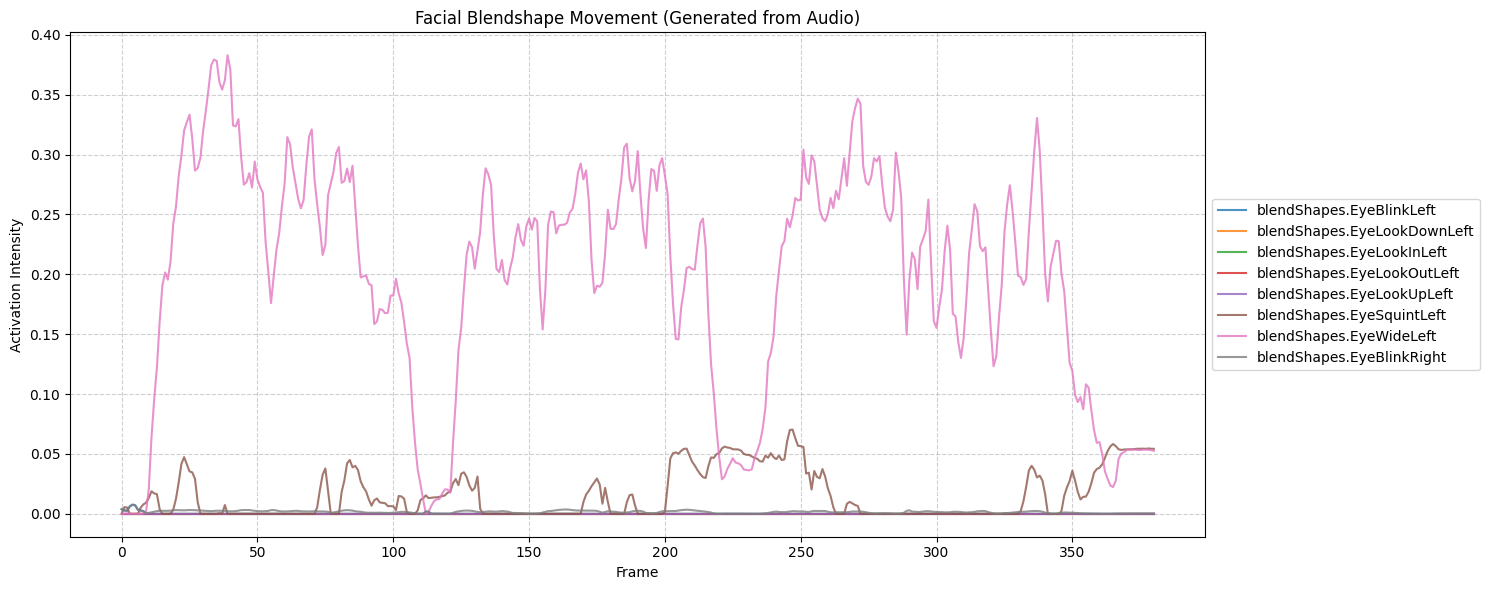


Interpretation: Each line shows a different facial muscle or expression (like mouth opening) changing over time to match the audio.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import Audio, display

# 1. Define the base path and find results
client_path = '/content/Audio2Face-3D-Samples/scripts/audio2face_3d_api_client'

# Search recursively for the files in the client directory
csv_files = sorted(glob.glob(os.path.join(client_path, '**/animation_frames.csv'), recursive=True))
wav_files = sorted(glob.glob(os.path.join(client_path, '**/out.wav'), recursive=True))

if csv_files and wav_files:
    latest_csv = csv_files[-1]
    latest_wav = wav_files[-1]

    df = pd.read_csv(latest_csv)
    print(f"Visualizing Animation Data from: {os.path.dirname(latest_csv)}")

    # 2. Play the Generated Audio
    print("\n--- Generated Audio Output ---")
    display(Audio(latest_wav))

    # 3. Plot key blendshapes to show 'movement'
    # These values (0 to 1) represent how much a specific face part moves
    available_cols = [c for c in df.columns if c not in ['time', 'frame', 'Unnamed: 0', 'timeCode']]
    show_cols = [c for c in available_cols if any(word in c.lower() for word in ['mouth', 'eye', 'jaw'])][:8]

    if not show_cols:
        show_cols = available_cols[:8]

    plt.figure(figsize=(15, 6))
    for col in show_cols:
        plt.plot(df.index, df[col], label=col, alpha=0.8)

    plt.title("Facial Blendshape Movement (Generated from Audio)")
    plt.xlabel("Frame")
    plt.ylabel("Activation Intensity")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print("\nInterpretation: Each line shows a different facial muscle or expression (like mouth opening) changing over time to match the audio.")
else:
    print(f"No animation files found. Please ensure you have run the generation cell (ac001c1e) successfully.")